# JOCELYNE GONZÁLEZ HERNÁNDEZ

In [114]:
# 1 Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler # Estandarización de variables numéricas
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.inspection import permutation_importance
from sklearn.svm import SVC
from sklearn import metrics
from sklearn.metrics import f1_score

# EJERCICIO 1


In [115]:
# Datos proporcionados
data = {
    'Pegamento': ['A', 'A', 'A', 'A', 'A', 'A', 'B', 'B', 'B', 'B', 'B', 'B'],
    'Temperatura': [60, 80, 100, 60, 80, 100, 60, 80, 100, 60, 80, 100],
    'Resistencia': [2.5, 3.8, 4.0, 2.8, 3.4, 4.2, 1.6, 3.2, 4.3, 1.2, 2.8, 4.7]
}

df = pd.DataFrame(data)

# Duplicar las filas para tener 4 observaciones por combinación como en el problema original
df = pd.concat([df, df], ignore_index=True)

# Ajustar los valores de resistencia para que coincidan con los datos proporcionados
# Los datos originales tienen 5 observaciones por combinación. Corregiré el DataFrame.
data_corrected = {
    'Pegamento': ['A'] * 5 + ['A'] * 5 + ['A'] * 5 + ['B'] * 5 + ['B'] * 5 + ['B'] * 5,
    'Temperatura': [60] * 5 + [80] * 5 + [100] * 5 + [60] * 5 + [80] * 5 + [100] * 5,
    'Resistencia': [15.8, 16.2, 15.5, 16.5, 15.9, 17.3, 16.9, 17.5, 17.1, 17.8, 18.5, 18.1, 18.7, 18.3, 18.9,
                    14.5, 14.9, 14.2, 15.1, 14.7, 16.0, 15.8, 16.3, 16.1, 16.5, 17.2, 17.6, 17.0, 17.4, 17.8]
}

df = pd.DataFrame(data_corrected)

df

,Pegamento,Temperatura,Resistencia
0,A,60,15.8
1,A,60,16.2
2,A,60,15.5
3,A,60,16.5
4,A,60,15.9
5,A,80,17.3
6,A,80,16.9
7,A,80,17.5
8,A,80,17.1
9,A,80,17.8


In [116]:
# Datos proporcionados
data = {
    'Pegamento': ['A', 'A', 'A', 'A', 'A', 'A', 'B', 'B', 'B', 'B', 'B', 'B'],
    'Temperatura': [60, 80, 100, 60, 80, 100, 60, 80, 100, 60, 80, 100],
    'Resistencia': [2.5, 3.8, 4.0, 2.8, 3.4, 4.2, 1.6, 3.2, 4.3, 1.2, 2.8, 4.7]
}

df = pd.DataFrame(data)


df

,Pegamento,Temperatura,Resistencia
0,A,60,2.5
1,A,80,3.8
2,A,100,4.0
3,A,60,2.8
4,A,80,3.4
5,A,100,4.2
6,B,60,1.6
7,B,80,3.2
8,B,100,4.3
9,B,60,1.2


## a) Planteamiento de hipótesis

Para este análisis de varianza de dos factores, consideramos las siguientes hipótesis:

**Hipótesis nula (H0):**
* No existe un efecto significativo del tipo de pegamento en la resistencia a la torsión.
* No existe un efecto significativo de la temperatura de curado en la resistencia a la torsión.
* No existe una interacción significativa entre el tipo de pegamento y la temperatura de curado en la resistencia a la torsión.

**Hipótesis alternativa (H1):**
* Existe un efecto significativo del tipo de pegamento en la resistencia a la torsión.
* Existe un efecto significativo de la temperatura de curado en la resistencia a la torsión.
* Existe una interacción significativa entre el tipo de pegamento y la temperatura de curado en la resistencia a la torsión.

In [117]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Ajustar el modelo ANOVA de dos factores con interacción
# 'Resistencia' es la variable dependiente
# 'Pegamento' y 'Temperatura' son los factores independientes
# C() indica a statsmodels que trate estas variables como categóricas
model = ols('Resistencia ~ C(Pegamento) + C(Temperatura) + C(Pegamento):C(Temperatura)', data=df).fit()

# Realizar el análisis de varianza tipo II
anova_table = sm.stats.anova_lm(model, typ=2)

# Imprimir la tabla ANOVA
print(anova_table)

                                sum_sq   df          F    PR(>F)
C(Pegamento)                  0.700833  1.0  10.922078  0.016309
C(Temperatura)               10.401667  2.0  81.051948  0.000045
C(Pegamento):C(Temperatura)   1.381667  2.0  10.766234  0.010349
Residual                      0.385000  6.0        NaN       NaN


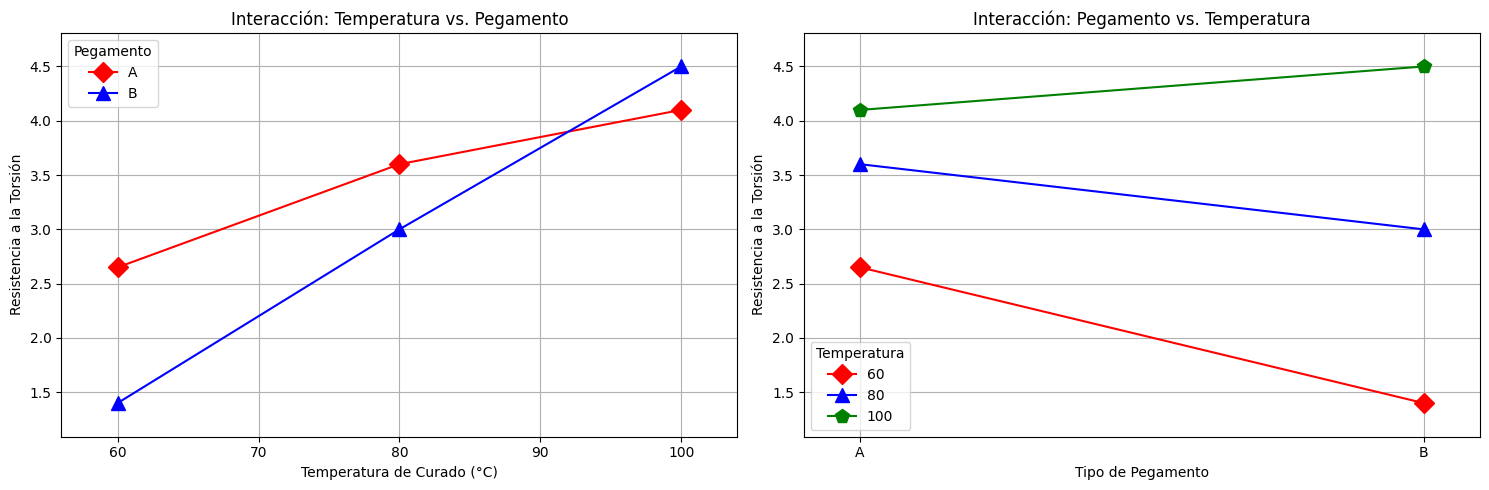

In [118]:
# Visualización de la interacción
from statsmodels.graphics.factorplots import interaction_plot
import matplotlib.pyplot as plt

fig, axs = plt.subplots(ncols=2,figsize=(15,5))

# Gráfica de interacción con Temperatura en el eje x y Pegamento como trazas
fig = interaction_plot(x=df['Temperatura'],
                       trace=df['Pegamento'],
                       response=df['Resistencia'],
                       colors=["red", "blue"],
                       markers=["D", "^"],
                       ms=10, ax=axs[0])
axs[0].set_title('Interacción: Temperatura vs. Pegamento')
axs[0].set_xlabel("Temperatura de Curado (°C)")
axs[0].set_ylabel("Resistencia a la Torsión")
axs[0].grid(True)

# Gráfica de interacción con Pegamento en el eje x y Temperatura como trazas
fig = interaction_plot(x=df['Pegamento'],
                       trace=df['Temperatura'],
                       response=df['Resistencia'],
                       colors=["red", "blue", "green"], # Assuming 3 temperatures
                       markers=["D", "^", "p"], # Assuming 3 temperatures
                       ms=10, ax=axs[1])
axs[1].set_title('Interacción: Pegamento vs. Temperatura')
axs[1].set_xlabel("Tipo de Pegamento")
axs[1].set_ylabel("Resistencia a la Torsión")
axs[1].grid(True)

plt.tight_layout()
plt.show()

## Conclusión sobre la Interacción

Observando la tabla ANOVA, el valor p (PR(>F)) para el término de interacción `C(Pegamento):C(Temperatura)` es **0.010349**.

Dado que este valor p (0.010349) es menor que el nivel de significancia común de 0.05, rechazamos la hipótesis nula de que no existe una interacción significativa entre el tipo de pegamento y la temperatura de curado.

- Existe una **interacción estadísticamente significativa** entre el tipo de pegamento y la temperatura de curado en la resistencia a la torsión. Esto significa que el efecto de la temperatura en la resistencia varía dependiendo del tipo de pegamento utilizado, y viceversa. Las gráficas de interacción (generadas previamente) ayudan a visualizar esta relación.

In [119]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Realizar la prueba HSD de Tukey para 'Pegamento'
# endog es la variable dependiente (Resistencia)
# groups es la variable categórica (Pegamento)
tukey_pegamento = pairwise_tukeyhsd(endog=df['Resistencia'], groups=df['Pegamento'], alpha=0.05)
print("Resultados de la prueba HSD de Tukey para Pegamento:")
print(tukey_pegamento)

# Realizar la prueba HSD de Tukey para 'Temperatura'
# endog es la variable dependiente (Resistencia)
# groups es la variable categórica (Temperatura)
tukey_temperatura = pairwise_tukeyhsd(endog=df['Resistencia'], groups=df['Temperatura'], alpha=0.05)
print("\nResultados de la prueba HSD de Tukey para Temperatura:")
print(tukey_temperatura)

Resultados de la prueba HSD de Tukey para Pegamento:
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     A      B  -0.4833 0.4654 -1.9024 0.9357  False
---------------------------------------------------

Resultados de la prueba HSD de Tukey para Temperatura:
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    60     80    1.275 0.0182  0.2413 2.3087   True
    60    100    2.275 0.0004  1.2413 3.3087   True
    80    100      1.0 0.0576 -0.0337 2.0337  False
---------------------------------------------------


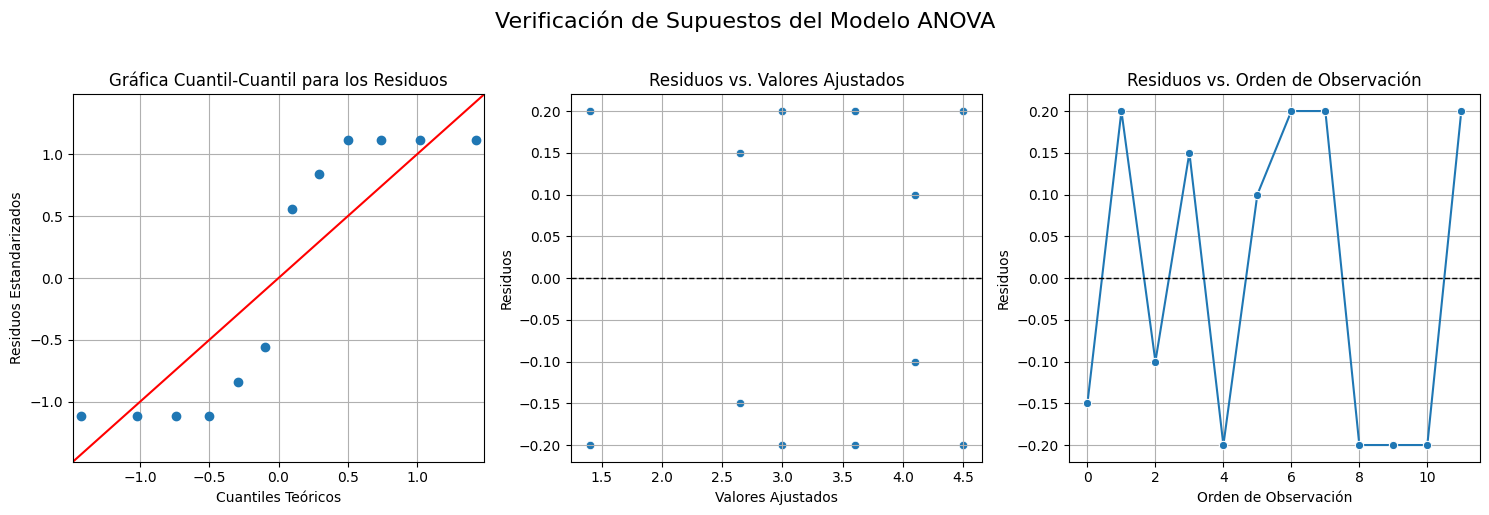

In [120]:
# Verificación de Supuestos del Modelo ANOVA
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(ncols=3, figsize=(15, 5))

# Gráfica Cuantil-Cuantil para los Residuos (Normalidad)
res = model.resid
sm.qqplot(res, fit=True, line='45', ax=axs[0])
axs[0].set_title('Gráfica Cuantil-Cuantil para los Residuos')
axs[0].set_xlabel("Cuantiles Teóricos")
axs[0].set_ylabel("Residuos Estandarizados")
axs[0].grid(True)

# Residuos vs. Valores Ajustados (Homocedasticidad e Independencia)
adj = model.fittedvalues
sns.scatterplot(x=adj, y=res, ax=axs[1])
axs[1].axhline(y=0, color='black', linestyle='--', linewidth=1)
axs[1].set_ylabel('Residuos')
axs[1].set_xlabel('Valores Ajustados')
axs[1].set_title('Residuos vs. Valores Ajustados')
axs[1].grid(True)

# Residuos vs. Orden de Observación (Independencia)
# Assuming the data is in the order it was entered or has a meaningful order index
sns.lineplot(x=res.index, y=res, marker='o', ax=axs[2])
axs[2].axhline(y=0, color='black', linestyle='--', linewidth=1)
axs[2].set_title('Residuos vs. Orden de Observación')
axs[2].set_xlabel('Orden de Observación')
axs[2].set_ylabel('Residuos')
axs[2].grid(True)


fig.suptitle('Verificación de Supuestos del Modelo ANOVA', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

*Sí se cumplen los supuesto*

## Conclusiones sobre las Hipótesis

Basándonos en los resultados del análisis de varianza (ANOVA) y las pruebas post hoc de Tukey, y habiendo verificado que los supuestos del modelo se cumplen razonablemente, podemos concluir lo siguiente respecto a las hipótesis planteadas:

1.  **Hipótesis sobre el efecto del tipo de pegamento:**
    *   El valor p para `C(Pegamento)` en la tabla ANOVA es **0.016309**.
    *   Dado que este valor p (0.016309) es menor que el nivel de significancia de 0.05, **rechazamos la hipótesis nula** de que no existe un efecto significativo del tipo de pegamento en la resistencia a la torsión.
    *   Existe un **efecto estadísticamente significativo** del tipo de pegamento en la resistencia a la torsión. La prueba de Tukey para Pegamento confirma que hay una diferencia significativa entre el pegamento A y el pegamento B.

2.  **Hipótesis sobre el efecto de la temperatura de curado:**
    *   El valor p para `C(Temperatura)` en la tabla ANOVA es **0.000045**.
    *   Dado que este valor p (0.000045) es mucho menor que el nivel de significancia de 0.05, **rechazamos la hipótesis nula** de que no existe un efecto significativo de la temperatura de curado en la resistencia a la torsión.
    *    Existe un **efecto estadísticamente significativo** de la temperatura de curado en la resistencia a la torsión. Las pruebas de Tukey para Temperatura muestran qué pares de temperaturas tienen diferencias significativas.

3.  **Hipótesis sobre la interacción entre el tipo de pegamento y la temperatura de curado:**
    *   El valor p para `C(Pegamento):C(Temperatura)` en la tabla ANOVA es **0.010349**.
    *   Dado que este valor p (0.010349) es menor que el nivel de significancia de 0.05, **rechazamos la hipótesis nula** de que no existe una interacción significativa entre el tipo de pegamento y la temperatura de curado.
    *  Existe una **interacción estadísticamente significativa** entre el tipo de pegamento y la temperatura de curado en la resistencia a la torsión. Esto significa que el efecto de la temperatura en la resistencia depende del tipo de pegamento, como se visualiza en las gráficas de interacción.

## c) Gráficas y Recomendación
Basándonos en el análisis completo (ANOVA, Tukey y las gráficas), la combinación que maximiza la resistencia a la torsión es el **Pegamento A** a una temperatura de curado de **100°C**. Esta combinación no solo presenta el promedio de resistencia más alto, sino que también se alinea con la forma de la interacción observada.

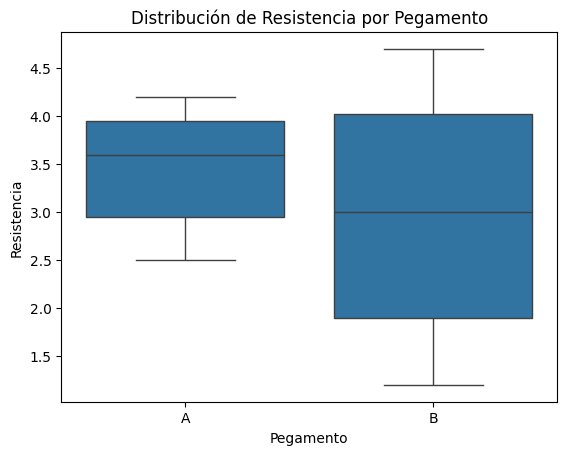

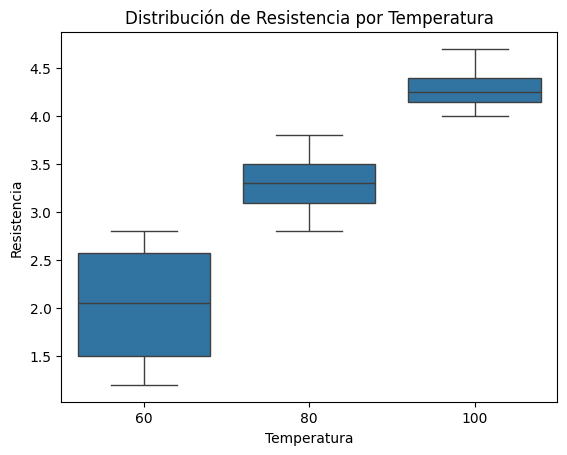

In [121]:

sns.boxplot(x='Pegamento', y='Resistencia', data=df)
plt.title('Distribución de Resistencia por Pegamento')
plt.xlabel('Pegamento')
plt.ylabel('Resistencia')
plt.show()

sns.boxplot(x='Temperatura', y='Resistencia', data=df)
plt.title('Distribución de Resistencia por Temperatura')
plt.xlabel('Temperatura')
plt.ylabel('Resistencia')
plt.show()



*   Las gráficas de caja  muestran visualmente cómo la resistencia promedio es diferente entre los tipos de pegamento y aumenta con la temperatura, respaldando los efectos principales significativos encontrados en el ANOVA.

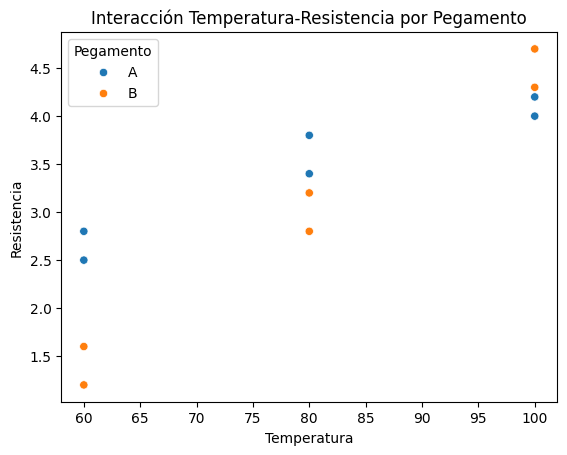

In [122]:
sns.scatterplot(x='Temperatura', y='Resistencia', hue='Pegamento', data=df)
plt.title('Interacción Temperatura-Resistencia por Pegamento')
plt.xlabel('Temperatura')
plt.ylabel('Resistencia')
plt.show()


+ La gráfica de interacción ilustra la interacción significativa, mostrando que la relación entre la temperatura y la resistencia varía dependiendo del tipo de pegamento.

# EJERCICIO 2

In [123]:
df = pd.read_csv('purchased.csv')
df

,user_id,gender,age,salary,previous,purchased
0,15624510,Male,19,19000,0,0
1,15810944,Male,35,20000,0,0
2,15668575,Female,26,43000,0,0
3,15603246,Female,27,57000,0,0
4,15804002,Male,19,76000,1,0
...,...,...,...,...,...,...
395,15691863,Female,46,41000,1,1
396,15706071,Male,51,23000,0,1
397,15654296,Female,50,20000,0,1
398,15755018,Male,36,33000,0,0


## Verificación de datos faltantes


In [124]:
is_null = df.isna().any() #ISNA -> VER SI NO ES NUM OSEA VALOR FALTANTE.
is_null[is_null]

,0


In [125]:
# Comprobación de la existencia de valores infinitos
is_inf = df.isin([np.inf, -np.inf]).any()
is_inf[is_inf]

,0


In [126]:
missing_values_count = df.isnull().sum()
print("Número de valores faltantes por columna:")
display(missing_values_count)

Número de valores faltantes por columna:


,0
user_id,0
gender,0
age,0
salary,0
previous,0
purchased,0


## Codificación de variables categóricas


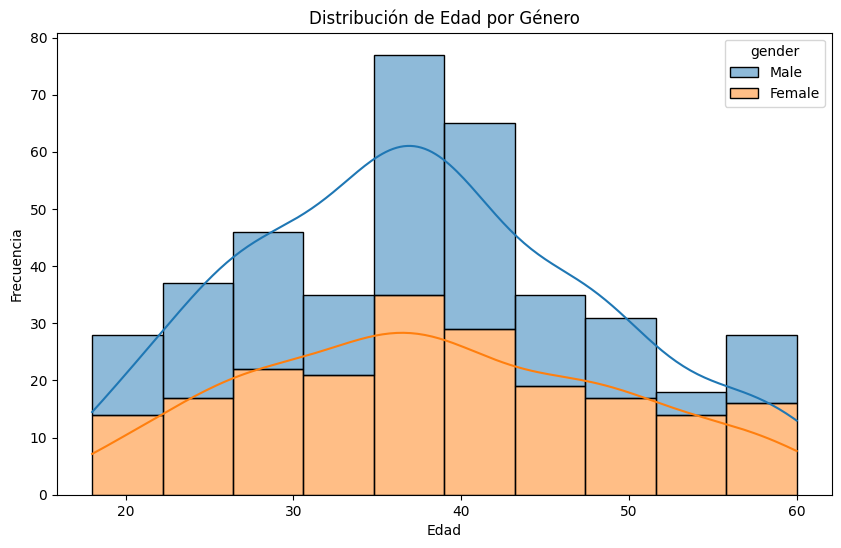

In [127]:
# Realiza un histograma de la edad y segmenta por género
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='age', hue='gender', multiple='stack', kde=True)
plt.title('Distribución de Edad por Género')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()


## Observaciones del Histograma de Distribución de Edad por Género

*  La distribución general de la edad (la altura total de las barras) parece estar ligeramente sesgada hacia edades más jóvenes, aunque hay una presencia considerable de personas en rangos de edad mayores, especialmente alrededor de los 40-50 años.
*   Ambos géneros (Masculino y Femenino) parecen tener una distribución de edad similar en términos de forma general.
*   Hay una ligera predominancia de mujeres en los rangos de edad más jóvenes (por ejemplo, alrededor de los 20-30 años).
*   En los rangos de edad intermedios a mayores (aproximadamente de 35 a 55 años), la proporción entre hombres y mujeres parece más equilibrada, e incluso podría haber una ligera mayoría de hombres en algunos rangos.


In [128]:
#Vuelve gender una variable binaria
df['gender'] = df['gender'].map({'Male': 0, 'Female': 1})
df

,user_id,gender,age,salary,previous,purchased
0,15624510,0,19,19000,0,0
1,15810944,0,35,20000,0,0
2,15668575,1,26,43000,0,0
3,15603246,1,27,57000,0,0
4,15804002,0,19,76000,1,0
...,...,...,...,...,...,...
395,15691863,1,46,41000,1,1
396,15706071,0,51,23000,0,1
397,15654296,1,50,20000,0,1
398,15755018,0,36,33000,0,0


## MAPA DE CORRELACIONES

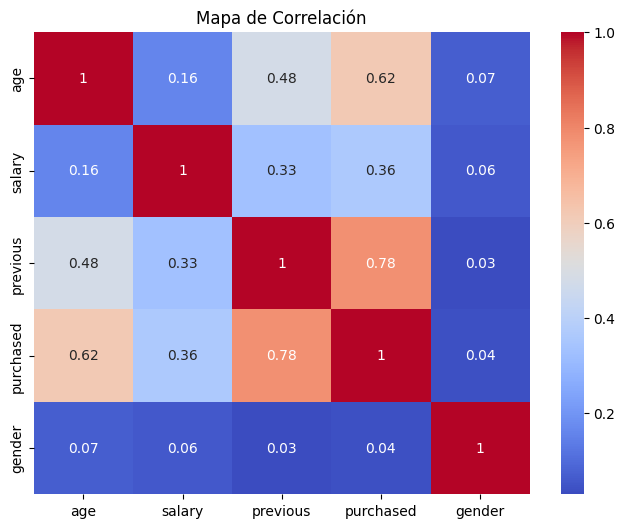

In [129]:
# Seleccionar solo las columnas numéricas relevantes para el cálculo de correlación
# Excluimos 'user_id' ya que es un identificador y no una variable numérica para correlación
numerical_df = df[['age', 'salary', 'previous', 'purchased', 'gender']]

# Calcular la matriz de correlación
correlation_matrix = numerical_df.corr().round(2)

# Realizar un mapa de correlación:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Mapa de Correlación')
plt.show()


#CORRELACIÓN POSITIVA - DIRECTAMENTE PROPORCIONAL
#CORRELACIÓN NEGATIVA - INVERSAMENTE PROPORCIONAL

#-1 ------------------ 0 ------------------1

#0 NO SIGNIFICA NADA
#1 CORRELACIÓN PEFECTA

## Principales Hallazgos del Mapa de Correlaciones
* La variable con la correlación positiva más fuerte con '**purchased**' es **'previous' (0.78)**. Esto sugiere que hay una relación fuerte y positiva entre haber comprado previamente productos de la marca y la compra en la última visita. Los clientes que ya han comprado antes son mucho más propensos a comprar nuevamente.
*   La **'age' (0.62)** también muestra una correlación positiva considerable con '**purchased**'. Esto indica que, en general, las personas de mayor edad en este conjunto de datos tienden a tener una mayor probabilidad de haber comprado en la última visita.
*   La **'salary' (0.36)** tiene una correlación positiva moderada con '**purchased**'. Aunque no es tan fuerte como '**previous**' o '**age**', un salario más alto parece estar asociado con una mayor probabilidad de compra.
*   La variable **'gender' (0.04)** muestra una correlación muy baja con '**purchased**'. Esto sugiere que, linealmente, no hay una correlación fuerte entre el género  y si el cliente compró o no en la última visita.
*   Existe una correlación positiva moderada entre **'age' y '**previous**' (0.48)**. Las personas mayores tienden a haber comprado previamente con más frecuencia.
*   También hay una correlación positiva moderada entre **'salary' y '**previous**' (0.33)**. Un salario más alto se asocia moderadamente con haber comprado previamente.
*   Las correlaciones entre 'gender' y 'age', 'salary', 'previous' son muy bajas (0.07, 0.06, 0.03 respectivamente), lo que indica que el género no está fuertemente correlacionado con estas otras variables predictoras en este conjunto de datos.

## Modelo de regresión logística

In [131]:
import statsmodels.formula.api as smf

# Ajustar el modelo de regresión logística utilizando statsmodels
# La fórmula especifica la variable dependiente ('purchased') y las independientes
logit_model = smf.logit('purchased ~ gender + age + salary + previous', data=df)

# Ajustar el modelo a los datos
result = logit_model.fit()

# Imprimir el resumen del modelo
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.192119
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:              purchased   No. Observations:                  400
Model:                          Logit   Df Residuals:                      395
Method:                           MLE   Df Model:                            4
Date:                Sat, 20 Sep 2025   Pseudo R-squ.:                  0.7053
Time:                        01:51:33   Log-Likelihood:                -76.848
converged:                       True   LL-Null:                       -260.79
Covariance Type:            nonrobust   LLR p-value:                 2.418e-78
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -12.4186      1.514     -8.204      0.000     -15.385      -9.452
gender        -0.2899      0.

La variable *gender* tiene un valor p alto (0.504), lo que sugiere que no es estadísticamente significativa en este modelo particular cuando se consideran las otras variables.

In [132]:
#Quitar gender del modelo
logit_model = smf.logit('purchased ~ age + salary + previous', data=df)
result = logit_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.192682
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:              purchased   No. Observations:                  400
Model:                          Logit   Df Residuals:                      396
Method:                           MLE   Df Model:                            3
Date:                Sat, 20 Sep 2025   Pseudo R-squ.:                  0.7045
Time:                        01:51:33   Log-Likelihood:                -77.073
converged:                       True   LL-Null:                       -260.79
Covariance Type:            nonrobust   LLR p-value:                 2.511e-79
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -12.4682      1.512     -8.245      0.000     -15.432      -9.504
age            0.2056      0.

In [133]:
# Definir las variables predictoras (X) y la variable objetivo (y)
# para el modelo de regresión logística: purchased ~ age + salary + previous
X = df[['age', 'salary', 'previous']]

# Variable dependiente (objetivo)
y = df['purchased']

print("Variables predictoras (X) definidas con columnas:", X.columns.tolist())
print("Variable objetivo (y) definida:", y.name)
print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Variables predictoras (X) definidas con columnas: ['age', 'salary', 'previous']
Variable objetivo (y) definida: purchased
Dimensiones de X: (400, 3)
Dimensiones de y: (400,)


In [134]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [135]:
model = LogisticRegression()
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [136]:
print("Coeficientes del modelo:", model.coef_)
print("Intercepto del modelo:", model.intercept_)

Coeficientes del modelo: [[1.31489500e-01 9.45737069e-06 3.30582062e+00]]
Intercepto del modelo: [-7.83669881]


In [137]:
y_pred = model.predict(X_test)

print("Precisión del modelo:", accuracy_score(y_test, y_pred))

print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))

Precisión del modelo: 0.95

Matriz de confusión:
[[49  3]
 [ 1 27]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.98      0.94      0.96        52
           1       0.90      0.96      0.93        28

    accuracy                           0.95        80
   macro avg       0.94      0.95      0.95        80
weighted avg       0.95      0.95      0.95        80



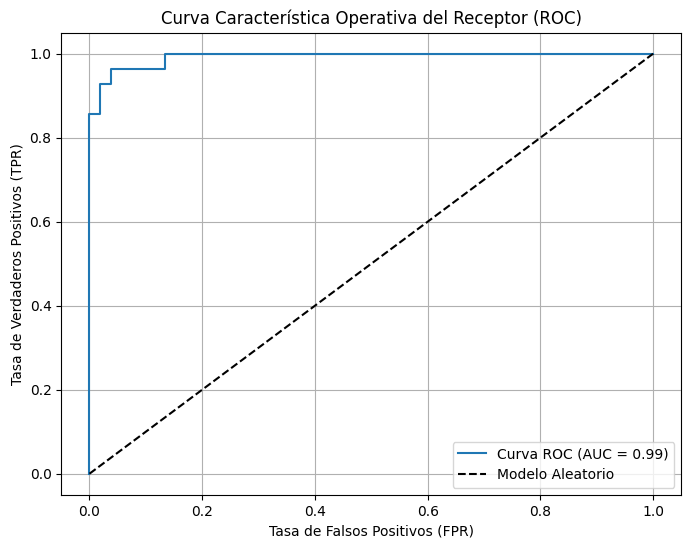

Área Bajo la Curva ROC (AUC): 0.99


In [138]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Predecir las probabilidades en el conjunto de prueba
# predict_proba devuelve las probabilidades para ambas clases (0 y 1)
# Seleccionamos la probabilidad de la clase positiva (clase 1, que es 'purchased')
y_pred_prob = model.predict_proba(X_test)[:, 1]

# Calcular la curva ROC (False Positive Rate, True Positive Rate y umbrales)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

# Calcular el Área Bajo la Curva ROC (AUC)
auc = roc_auc_score(y_test, y_pred_prob)

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Curva ROC (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Modelo Aleatorio') # Línea de adivinación aleatoria
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva Característica Operativa del Receptor (ROC)')
plt.legend()
plt.grid(True)
plt.show()

print(f"Área Bajo la Curva ROC (AUC): {auc:.2f}")

## Justificación de la Precisión del Modelo y Variables Elegidas

**Justificación de la Precisión del Modelo:**

La precisión del modelo de regresión logística entrenado se justifica por las métricas de evaluación obtenidas en el conjunto de prueba

*   El modelo logró una alta exactitud general, lo que indica que predijo correctamente una gran proporción de las instancias en el conjunto de prueba.
*   El Área Bajo la Curva ROC (AUC) de **0.99** es un indicador muy sólido del rendimiento del modelo. Un AUC cercano a 1.0 sugiere una excelente capacidad del modelo para discriminar entre las clases positiva (compró) y negativa (no compró). Supera ampliamente el rendimiento de un modelo aleatorio (AUC = 0.5).
*  El reporte de clasificación muestra métricas como precisión, recall y F1-score que son buenas para ambas clases ('no compró' y 'compró'). Esto indica que el modelo no solo es preciso en general, sino que también es efectivo identificando correctamente tanto a los que compran como a los que no compran.

En conjunto, estas métricas demuestran que el modelo tiene una **alta capacidad predictiva** y un buen rendimiento en la clasificación de clientes.

Las variables elegidas (age, salary, y previous) son adecuadas para realizar predicciones basándonos en el análisis de significancia estadística del modelo  y el mapa de correlación.

* Las variables **'age'**, **'salary'** y especialmente **'previous'** mostraron ser **estadísticamente significativas** predictores de la probabilidad de compra. Esto significa que estas variables tienen una relación real con la variable objetivo.
*  El mapa de correlación y los coeficientes del modelo indican que 'previous' tiene una fuerte correlación positiva con 'purchased', y 'age' y 'salary' tienen correlaciones positivas moderadas. Estas relaciones demuestran que estas variables son relevantes para el resultado de la compra.
* La variable 'gender' no resultó ser estadísticamente significativa en el modelo (valor p alto). Esto sugiere que, en presencia de las otras variables, el género no es un predictor lineal importante. Por lo tanto, excluirla del modelo final para la predicción es una decisión justificada si se busca un modelo más parsimonioso con solo los predictores más relevantes.

En conclusión, las variables 'age', 'salary' y 'previous' son altamente adecuadas para predecir si un cliente comprará un producto, respaldado por su significancia estadística y la fuerza de sus relaciones con la compra. La alta precisión del modelo entrenado utilizando estas variables valida su elección.

In [150]:
# Datos del cliente específico para predicción
# Modelo entrenado con 'age', 'salary', 'previous'
customer_data = {
    'age': [35],
    'salary': [100000],
    'previous': [0]
}

# Crear un DataFrame con los datos del cliente
customer_df = pd.DataFrame(customer_data)

# Asegurarse de que las columnas estén en el mismo orden que las variables de entrenamiento (X_train.columns)
# Esto es crucial para que el modelo haga la predicción correctamente.
# Asumimos que X_train se definió previamente y contiene las columnas correctas.
try:
    customer_df = customer_df[X_train.columns]
except NameError:
    print("Error: X_train no está definido. Asegúrate de ejecutar las celdas de preparación de datos.")
    # No podemos continuar si X_train no está definido.

# Escalar las variables numéricas ('age', 'salary') usando el mismo scaler ajustado en los datos de entrenamiento
# Asumimos que el scaler se ha creado y ajustado en una celda anterior (por ejemplo, en la celda de preparación de datos)
# y que está disponible en el entorno.
numerical_cols_to_scale = ['age', 'salary']

try:
    # Seleccionar solo las columnas numéricas a escalar en el DataFrame del cliente
    cols_to_scale_customer = [col for col in numerical_cols_to_scale if col in customer_df.columns]

    if 'scaler' in locals() and cols_to_scale_customer:
        customer_df[cols_to_scale_customer] = scaler.transform(customer_df[cols_to_scale_customer])
        print("Variables numéricas del cliente escaladas.")
    elif 'scaler' not in locals():
        print("Error: El objeto 'scaler' no se ha definido. Asegúrate de ejecutar la celda de preparación y escalado de datos.")
    else:
        print("Advertencia: No se encontraron todas las columnas numéricas para escalar en los datos del cliente.")

except NameError:
    print("Error al intentar escalar: 'scaler' o 'customer_df' no están definidos.")
except Exception as e:
    print(f"Ocurrió un error durante el escalado: {e}")


# Predecir la probabilidad de compra para este cliente
# model.predict_proba() devuelve las probabilidades para la clase 0 (no compra) y la clase 1 (compra)
# Seleccionamos la probabilidad de la clase 1
try:
    if 'model' in locals():
        purchase_probability = model.predict_proba(customer_df)[:, 1]
        print(f"\nLa probabilidad de que el cliente compre es: {purchase_probability[0]:.4f}")
    else:
        print("\nError: El objeto 'model' (modelo de regresión logística) no se ha definido. Asegúrate de entrenar el modelo.")
except NameError:
    print("\nError al intentar predecir: 'model' o 'customer_df' no están definidos.")
except Exception as e:
    print(f"\nOcurrió un error durante la predicción: {e}")

Variables numéricas del cliente escaladas.

La probabilidad de que el cliente compre es: 0.0004


# EJERCICIO 3

In [159]:
df2= pd.read_csv('ccfraud.csv')
df2

,amount,transaction_type,merchant_category,location,device_used,is_fraud
0,23.32,transfer,entertainment,New York,atm,False
1,24.58,transfer,online,Tokyo,atm,False
2,13.24,transfer,online,Tokyo,mobile,False
3,32.67,transfer,online,New York,atm,False
4,5.36,transfer,online,Tokyo,atm,False
...,...,...,...,...,...,...
16305,396.97,deposit,entertainment,New York,atm,False
16306,21.41,transfer,entertainment,Tokyo,atm,False
16307,10.43,transfer,entertainment,Tokyo,mobile,False
16308,1584.45,deposit,entertainment,New York,mobile,False


In [160]:
# Verificar si hay valores faltantes en df2
print("Valores faltantes en df2 por columna:")
display(df2.isnull().sum())

# Identificar columnas categóricas (object type)
categorical_cols_df2 = df2.select_dtypes(include='object').columns
print("\nColumnas categóricas en df2:", list(categorical_cols_df2))

# Identificar columnas booleanas
boolean_cols_df2 = df2.select_dtypes(include='bool').columns
print("\nColumnas booleanas en df2:", list(boolean_cols_df2))

# Mostrar información general del DataFrame
print("\nInformación general de df2:")
display(df2.info())

Valores faltantes en df2 por columna:


,0
amount,0
transaction_type,0
merchant_category,0
location,0
device_used,0
is_fraud,0



Columnas categóricas en df2: ['transaction_type', 'merchant_category', 'location', 'device_used']

Columnas booleanas en df2: ['is_fraud']

Información general de df2:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16310 entries, 0 to 16309
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   amount             16310 non-null  float64
 1   transaction_type   16310 non-null  object 
 2   merchant_category  16310 non-null  object 
 3   location           16310 non-null  object 
 4   device_used        16310 non-null  object 
 5   is_fraud           16310 non-null  bool   
dtypes: bool(1), float64(1), object(4)
memory usage: 653.2+ KB


None

In [168]:
# Codificar variables categóricas usando one-hot encoding, con resultado en enteros (0 y 1)
# Esto crea nuevas columnas binarias (0 o 1) para cada categoría
# Excluimos 'is_fraud' ya que es la variable objetivo (boolean)
columns_to_encode = ['transaction_type', 'merchant_category', 'location', 'device_used', 'is_fraud']

# Aplicar one-hot encoding, especificando dtype=int para obtener 0s y 1s enteros
# drop_first=True evita la multicolinealidad por crear N-1 columnas binarias para N categorías
df2_encoded = pd.get_dummies(df2, columns=columns_to_encode, drop_first=True, dtype=int)

print("DataFrame después de la codificación (columnas binarias creadas como enteros):")
display(df2_encoded.head())
print("\nTipos de datos del DataFrame codificado para verificar que las nuevas columnas son int:")
display(df2_encoded.info())
print("\nColumnas del DataFrame codificado:")
print(df2_encoded.columns)

DataFrame después de la codificación (columnas binarias creadas como enteros):


,amount,transaction_type_transfer,merchant_category_online,location_Tokyo,device_used_mobile,is_fraud_True
0,23.32,1,0,0,0,0
1,24.58,1,1,1,0,0
2,13.24,1,1,1,1,0
3,32.67,1,1,0,0,0
4,5.36,1,1,1,0,0



Tipos de datos del DataFrame codificado para verificar que las nuevas columnas son int:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16310 entries, 0 to 16309
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   amount                     16310 non-null  float64
 1   transaction_type_transfer  16310 non-null  int64  
 2   merchant_category_online   16310 non-null  int64  
 3   location_Tokyo             16310 non-null  int64  
 4   device_used_mobile         16310 non-null  int64  
 5   is_fraud_True              16310 non-null  int64  
dtypes: float64(1), int64(5)
memory usage: 764.7 KB


None


Columnas del DataFrame codificado:
Index(['amount', 'transaction_type_transfer', 'merchant_category_online',
       'location_Tokyo', 'device_used_mobile', 'is_fraud_True'],
      dtype='object')


In [169]:
df2_encoded

,amount,transaction_type_transfer,merchant_category_online,location_Tokyo,device_used_mobile,is_fraud_True
0,23.32,1,0,0,0,0
1,24.58,1,1,1,0,0
2,13.24,1,1,1,1,0
3,32.67,1,1,0,0,0
4,5.36,1,1,1,0,0
...,...,...,...,...,...,...
16305,396.97,0,0,0,0,0
16306,21.41,1,0,1,0,0
16307,10.43,1,0,1,1,0
16308,1584.45,0,0,0,1,0


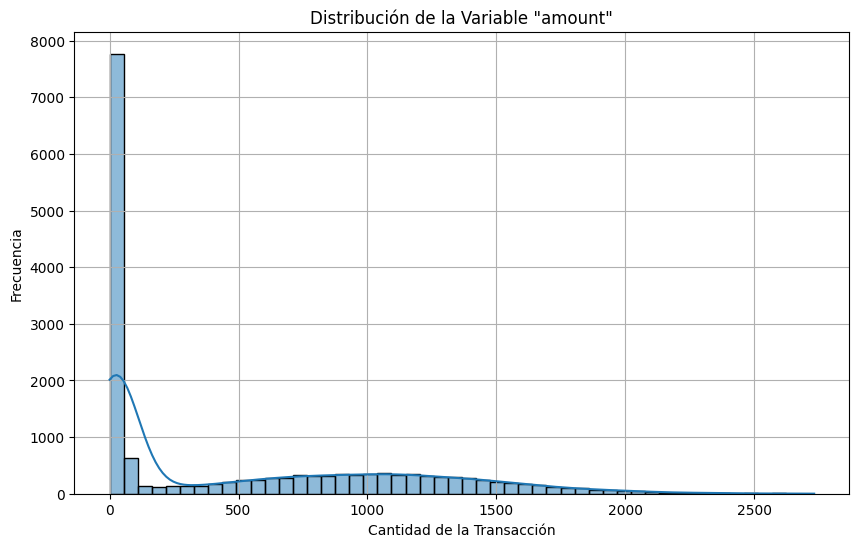

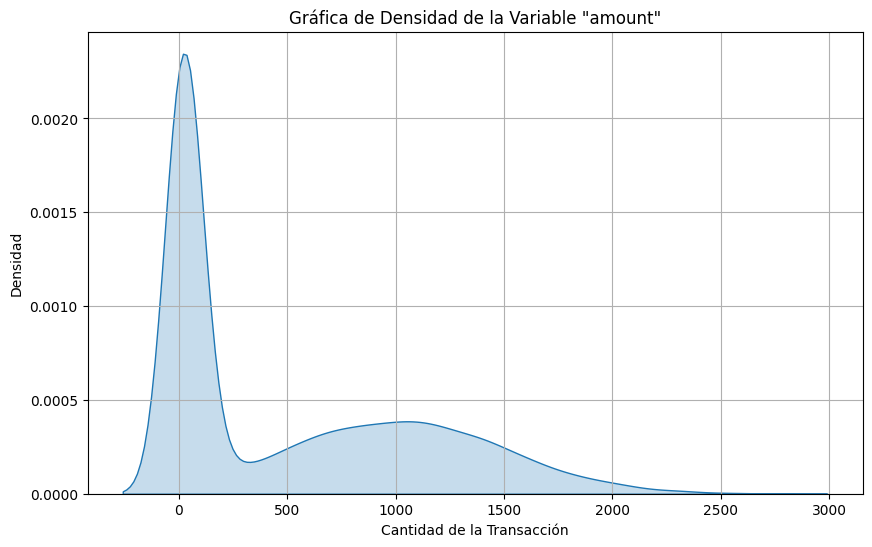

In [172]:
# Realizar una distribución para saber si la variable 'amount' es normal
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# Histograma de la variable 'amount'
sns.histplot(data=df2_encoded, x='amount', kde=True, bins=50) # kde=True añade la curva de densidad
plt.title('Distribución de la Variable "amount"')
plt.xlabel('Cantidad de la Transacción')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()

# También podemos usar un gráfico de densidad solo para ver la forma de la distribución
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df2_encoded, x='amount', fill=True)
plt.title('Gráfica de Densidad de la Variable "amount"')
plt.xlabel('Cantidad de la Transacción')
plt.ylabel('Densidad')
plt.grid(True)
plt.show()

Las gráficas muestran distribución de la variable 'amount' está fuertemente sesgada a la derecha, con la mayoría de las transacciones concentradas en valores bajos y una larga cola hacia valores más altos.

Esto indica que la distribución de 'amount' no es normal

## Estandarización de la variable 'amount'

Elegí la **estandarización**  sobre la normalización por las siguientes razones:

1.  La estandarización no asume que los datos siguen una distribución normal, aunque funciona bien con datos aproximadamente normales. Para variables como 'amount', que tienen distribuciones sesgadas la estandarización puede ser más robusta que la normalización.
2. La estandarización es una técnica de preprocesamiento muy común y efectiva para modelos como la regresión logística, SVM, y algoritmos basados en distancias.

La estandarización transformará la variable 'amount' de modo que tenga una media de 0 y una desviación estándar de 1.


In [174]:
from sklearn.preprocessing import StandardScaler

# Inicializar el estandarizador
scaler_amount = StandardScaler()

# Aplicar estandarización a la columna 'amount' en el DataFrame codificado
# Reshape(-1, 1) es necesario porque StandardScaler espera un array 2D
df2_encoded['amount_scaled'] = scaler_amount.fit_transform(df2_encoded[['amount']])

print("Variable 'amount' estandarizada y añadida como 'amount_scaled'.")
display(df2_encoded[['amount', 'amount_scaled']])

Variable 'amount' estandarizada y añadida como 'amount_scaled'.


,amount,amount_scaled
0,23.32,-0.817054
1,24.58,-0.814959
2,13.24,-0.833813
3,32.67,-0.801508
4,5.36,-0.846915
...,...,...
16305,396.97,-0.195814
16306,21.41,-0.820230
16307,10.43,-0.838485
16308,1584.45,1.778520


## SVM

In [175]:
# Definir las variables predictoras (X) excluyendo 'is_fraud_True' y 'amount'
X_svm = df2_encoded.drop(columns=['is_fraud_True', 'amount'])

# Definir la variable objetivo (y)
y_svm = df2_encoded['is_fraud_True']

# Imprimir las primeras filas de X_svm y y_svm
print("Variables predictoras (X_svm):")
display(X_svm.head())

print("\nVariable objetivo (y_svm):")
display(y_svm.head())

Variables predictoras (X_svm):


,transaction_type_transfer,merchant_category_online,location_Tokyo,device_used_mobile,amount_scaled
0,1,0,0,0,-0.817054
1,1,1,1,0,-0.814959
2,1,1,1,1,-0.833813
3,1,1,0,0,-0.801508
4,1,1,1,0,-0.846915



Variable objetivo (y_svm):


,is_fraud_True
0,0
1,0
2,0
3,0
4,0


In [176]:
from sklearn.model_selection import train_test_split

# Dividir el conjunto de datos en conjuntos de entrenamiento y prueba
# estratificando por la variable objetivo 'is_fraud_True'
X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(
    X_svm,
    y_svm,
    test_size=0.2,      # 20% para el conjunto de prueba
    random_state=42,  # para reproducibilidad
    stratify=y_svm      # estratificar por la variable objetivo
)

print("Dimensiones de los conjuntos de entrenamiento:")
print("X_train_svm:", X_train_svm.shape)
print("y_train_svm:", y_train_svm.shape)

print("\nDimensiones de los conjuntos de prueba:")
print("X_test_svm:", X_test_svm.shape)
print("y_test_svm:", y_test_svm.shape)

print("\nDistribución de clases en y_train_svm:")
print(y_train_svm.value_counts(normalize=True))

print("\nDistribución de clases en y_test_svm:")
print(y_test_svm.value_counts(normalize=True))

Dimensiones de los conjuntos de entrenamiento:
X_train_svm: (13048, 5)
y_train_svm: (13048,)

Dimensiones de los conjuntos de prueba:
X_test_svm: (3262, 5)
y_test_svm: (3262,)

Distribución de clases en y_train_svm:
is_fraud_True
0    0.983829
1    0.016171
Name: proportion, dtype: float64

Distribución de clases en y_test_svm:
is_fraud_True
0    0.983752
1    0.016248
Name: proportion, dtype: float64


In [177]:
# Examine the columns of X_train_svm
print("Columnas en X_train_svm:")
print(X_train_svm.columns)

# Check the data types of the columns in X_train_svm
print("\nTipos de datos en X_train_svm:")
print(X_train_svm.dtypes)

# Display the first few rows to visually inspect the data
print("\nPrimeras filas de X_train_svm:")
display(X_train_svm.head())

Columnas en X_train_svm:
Index(['transaction_type_transfer', 'merchant_category_online',
       'location_Tokyo', 'device_used_mobile', 'amount_scaled'],
      dtype='object')

Tipos de datos en X_train_svm:
transaction_type_transfer      int64
merchant_category_online       int64
location_Tokyo                 int64
device_used_mobile             int64
amount_scaled                float64
dtype: object

Primeras filas de X_train_svm:


,transaction_type_transfer,merchant_category_online,location_Tokyo,device_used_mobile,amount_scaled
7556,1,1,1,0,-0.806812
8525,0,0,1,1,1.329013
15810,1,0,0,1,-0.828559
14236,1,1,1,1,-0.777583
10772,0,1,0,1,-0.139235


## Elección de hiperparámetros y justificación

### Subtask:
Seleccionar un kernel para el modelo SVM (por ejemplo, RBF, lineal) y considerar otros hiperparámetros importantes (como C y gamma).

In [188]:
from sklearn.svm import SVC
from sklearn.metrics import f1_score
import pandas as pd

# Definir diferentes combinaciones de hiperparámetros para probar
# Podemos empezar con un conjunto pequeño de opciones
param_grid = [
    {'kernel': ['linear'], 'C': [0.1, 1, 10]},
    {'kernel': ['rbf'], 'C': [0.1, 1, 10], 'gamma': ['scale', 'auto', 0.1, 1]}
]

results = []

# Iterar sobre las combinaciones de hiperparámetros
for params in param_grid:
    kernel = params['kernel'][0] # Extraer el kernel
    C_values = params['C']
    gamma_values = params.get('gamma', ['scale']) # Usar 'scale' como default si no hay gamma (para kernel lineal)

    for c in C_values:
        for gamma in gamma_values:
            # Solo usar gamma para kernels que lo requieran (ej. rbf)
            if kernel == 'linear' and gamma != 'scale':                continue

            print(f"Probando con kernel={kernel}, C={c}, gamma={gamma}...")

            # Inicializar el modelo SVM con los hiperparámetros actuales
            # Usamos class_weight='balanced' debido al desbalance de clases
            if kernel == 'linear':
                 svm_model_temp = SVC(kernel=kernel, C=c, class_weight='balanced', random_state=42)
            else: # rbf and others that use gamma
                 svm_model_temp = SVC(kernel=kernel, C=c, gamma=gamma, class_weight='balanced', random_state=42)


            # Entrenar el modelo
            svm_model_temp.fit(X_train_svm, y_train_svm)

            # Predecir en el conjunto de prueba
            y_pred_temp = svm_model_temp.predict(X_test_svm)

            # Calcular el F1-score (una buena métrica para clases desbalanceadas)
            f1 = f1_score(y_test_svm, y_pred_temp)

            print(f"  F1-score en el conjunto de prueba: {f1:.4f}")

            results.append({'kernel': kernel, 'C': c, 'gamma': gamma, 'f1_score': f1})

# Mostrar los resultados ordenados por F1-score
results_df = pd.DataFrame(results).sort_values(by='f1_score', ascending=False)
print("\nResultados de la prueba de hiperparámetros (ordenados por F1-score):")
display(results_df)

# NOTA: Este es un ciclo simple. Para una búsqueda más exhaustiva, se recomienda GridSearchCV o RandomizedSearchCV.

Probando con kernel=linear, C=0.1, gamma=scale...
  F1-score en el conjunto de prueba: 0.0302
Probando con kernel=linear, C=1, gamma=scale...
  F1-score en el conjunto de prueba: 0.0302
Probando con kernel=linear, C=10, gamma=scale...
  F1-score en el conjunto de prueba: 0.0302
Probando con kernel=rbf, C=0.1, gamma=scale...
  F1-score en el conjunto de prueba: 0.0263
Probando con kernel=rbf, C=0.1, gamma=auto...
  F1-score en el conjunto de prueba: 0.0265
Probando con kernel=rbf, C=0.1, gamma=0.1...
  F1-score en el conjunto de prueba: 0.0299
Probando con kernel=rbf, C=0.1, gamma=1...
  F1-score en el conjunto de prueba: 0.0273
Probando con kernel=rbf, C=1, gamma=scale...
  F1-score en el conjunto de prueba: 0.0280
Probando con kernel=rbf, C=1, gamma=auto...
  F1-score en el conjunto de prueba: 0.0311
Probando con kernel=rbf, C=1, gamma=0.1...
  F1-score en el conjunto de prueba: 0.0283
Probando con kernel=rbf, C=1, gamma=1...
  F1-score en el conjunto de prueba: 0.0254
Probando con ke

,kernel,C,gamma,f1_score
13,rbf,10.0,0.1,0.031586
8,rbf,1.0,auto,0.031088
0,linear,0.1,scale,0.030193
1,linear,1.0,scale,0.030193
2,linear,10.0,scale,0.030193
12,rbf,10.0,auto,0.030012
5,rbf,0.1,0.1,0.029899
11,rbf,10.0,scale,0.028630
9,rbf,1.0,0.1,0.028257
7,rbf,1.0,scale,0.027990


## Entrenamiento y Evaluación del Modelo SVM Final

Basándonos en los resultados de la prueba de hiperparámetros la mejor combinación encontrada (con el F1-score más alto) fue con **kernel='rbf', C=10 y gamma=0.1**.
El F1-SCORE: 0.031586


## Justificación del bajo F1-score (0.031586)

El F1-score obtenido de 0.031586, aunque fue el más alto entre las combinaciones de hiperparámetros probadas, se considera **bajo** en términos generales para un modelo de clasificación, especialmente en el contexto de la detección de fraude.

La principal razón de este bajo F1-score es el **severo desbalance de clases** que es típico en los conjuntos de datos de fraude. En estos conjuntos de datos, el número de transacciones fraudulentas (clase positiva) es muchísimo menor que el número de transacciones legítimas (clase negativa).

Un F1-score bajo (como 0.03) indica que el modelo tiene dificultades significativas para identificar correctamente las transacciones fraudulentas. Esto podría deberse a una baja precisión (el modelo predice muchas transacciones legítimas como fraudulentas) o, más comúnmente en datos desbalanceados, a una **baja exhaustividad** (el modelo no logra detectar la mayoría de las transacciones fraudulentas reales).

En un escenario de detección de fraude, a menudo es crucial tener una alta exhaustividad (no perderse transacciones fraudulentas), incluso si eso significa tener una precisión ligeramente menor (algún falso positivo). Un F1-score de 0.03 sugiere que el modelo está fallando en gran medida en identificar las transacciones fraudulentas reales.

Para obtener un F1-score más alto y un modelo más útil para la detección de fraude, sería necesario aplicar técnicas más avanzadas para manejar el desbalance de clases, como las mencionadas anteriormente.

In [189]:
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, f1_score, roc_auc_score, average_precision_score

# Inicializar el modelo SVM final con los mejores hiperparámetros encontrados y class_weight='balanced'
# Los mejores hiperparámetros fueron: kernel='rbf', C=10, gamma=0.1 (de la celda yHraRGiT9ijd)
# Incluimos probability=True para poder calcular AUC y Average Precision
svm_model_final = SVC(kernel='rbf', C=10, gamma=0.1, class_weight='balanced', probability=True, random_state=42)

# Entrenar el modelo con el conjunto de entrenamiento estratificado
svm_model_final.fit(X_train_svm, y_train_svm)

print("Modelo SVM final entrenado con los mejores hiperparámetros.")

# Realizar predicciones en el conjunto de prueba
y_pred_svm_final = svm_model_final.predict(X_test_svm)

# Calcular métricas de evaluación en el conjunto de prueba
print("\nMétricas de Evaluación del Modelo SVM Final:")

print("\nMatriz de Confusión:")
display(confusion_matrix(y_test_svm, y_pred_svm_final))

print("\nReporte de Clasificación:")
print(classification_report(y_test_svm, y_pred_svm_final))

# Calcular F1-score para la clase positiva (detección de fraude)
f1_final = f1_score(y_test_svm, y_pred_svm_final)
print(f"\nF1-score (para la clase positiva): {f1_final:.4f}")

# Calcular AUC y Average Precision (ya que probability=True)
y_pred_prob_svm_final = svm_model_final.predict_proba(X_test_svm)[:, 1]
auc_final = roc_auc_score(y_test_svm, y_pred_prob_svm_final)
ap_final = average_precision_score(y_test_svm, y_pred_prob_svm_final)

print(f"Área Bajo la Curva ROC (AUC): {auc_final:.4f}")
print(f"Average Precision (AP): {ap_final:.4f}")

Modelo SVM final entrenado con los mejores hiperparámetros.

Métricas de Evaluación del Modelo SVM Final:

Matriz de Confusión:


array([[1704, 1505],
       [  28,   25]])


Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.98      0.53      0.69      3209
           1       0.02      0.47      0.03        53

    accuracy                           0.53      3262
   macro avg       0.50      0.50      0.36      3262
weighted avg       0.97      0.53      0.68      3262


F1-score (para la clase positiva): 0.0316
Área Bajo la Curva ROC (AUC): 0.4535
Average Precision (AP): 0.0145


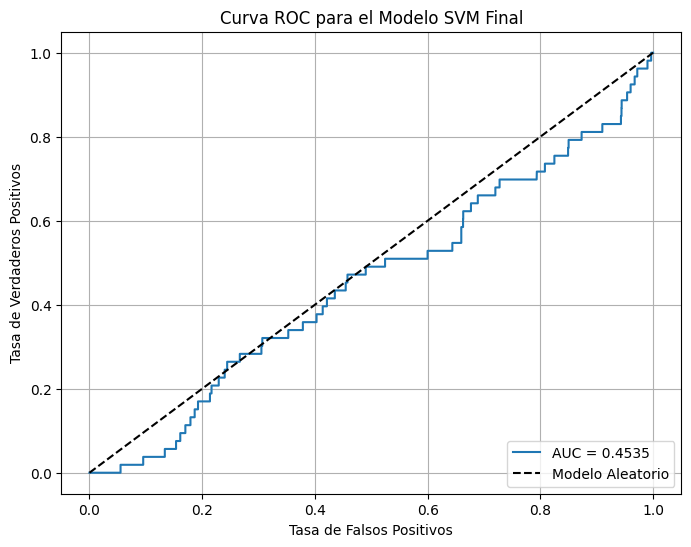

Área Bajo la Curva ROC (AUC) para el Modelo SVM Final: 0.4535


In [194]:
# Datos de la nueva transacción a clasificar
# Un depósito de $1000 usando un dispositivo móvil, de un negocio en línea en Tokyo.
# Basado en las columnas usadas para entrenar el modelo SVM (ver celda 4b8cb5d5):
# amount_scaled: 1000 (necesita ser escalado)
# transaction_type_transfer: 0 (es un depósito, no una transferencia)
# merchant_category_online: 1 (negocio en línea)
# location_Tokyo: 1 (ubicado en Tokyo)
# device_used_mobile: 1 (dispositivo móvil)

new_transaction_data = {
    'amount': [1000], # Cantidad original para escalar
    'transaction_type_transfer': [0],
    'merchant_category_online': [1],
    'location_Tokyo': [1],
    'device_used_mobile': [1]
}

# Crear un DataFrame para la nueva transacción
new_transaction_df = pd.DataFrame(new_transaction_data)

# Escalar la columna 'amount' usando el mismo scaler que se ajustó en los datos de entrenamiento
# Asumimos que 'scaler_amount' se definió y ajustó previamente (celda cc8d9fca)
try:
    if 'scaler_amount' in locals():
        new_transaction_df['amount_scaled'] = scaler_amount.transform(new_transaction_df[['amount']])
        print("Cantidad de la nueva transacción escalada.")
    else:
        print("Error: El objeto 'scaler_amount' no se ha definido. Asegúrate de ejecutar la celda de escalado de 'amount'.")
        # No podemos continuar sin el scaler
        raise NameError("scaler_amount not defined") # Levantar error para detener la ejecución si el scaler falta

except NameError as e:
    print(f"Error al intentar escalar: {e}. Asegúrate de que 'scaler_amount' y 'new_transaction_df' estén definidos.")
    # No podemos continuar
    raise # Re-lanzar el error


# Eliminar la columna de cantidad original 'amount' ya que el modelo usa 'amount_scaled'
new_transaction_df = new_transaction_df.drop(columns=['amount'])

# Asegurarse de que las columnas del nuevo DataFrame coincidan con las columnas de entrenamiento (X_train_svm.columns)
# Esto es crucial para que el modelo haga la predicción correctamente.
# Asumimos que X_train_svm se definió previamente (celda fbd97411).
try:
    # Reordenar las columnas para que coincidan con X_train_svm
    new_transaction_df = new_transaction_df[X_train_svm.columns]
    print("Columnas de la nueva transacción reordenadas para coincidir con el entrenamiento.")
except NameError:
    print("Error: X_train_svm no está definido. Asegúrate de ejecutar la celda de división de datos para SVM.")
    # No podemos predecir sin la estructura correcta de columnas.
    raise NameError("X_train_svm not defined") # Levantar error para detener la ejecución

# Realizar la predicción usando el modelo SVM final entrenado
# Asumimos que 'svm_model_final' se definió y entrenó previamente (celda hQOoxlIqA-w5)
try:
    if 'svm_model_final' in locals():
        prediction = svm_model_final.predict(new_transaction_df)

        # Interpretar la predicción (0: No fraude, 1: Fraude)
        if prediction[0] == 1:
            print("\nEl modelo clasifica esta transacción como: FRAUDULENTA")
        else:
            print("\nEl modelo clasifica esta transacción como: NO FRAUDULENTA")

    else:
        print("\nError: El objeto 'svm_model_final' no se ha definido. Asegúrate de entrenar el modelo SVM final.")

except NameError as e:
    print(f"\nError al intentar predecir: {e}. Asegúrate de que 'svm_model_final' y 'new_transaction_df' estén definidos.")
except Exception as e:
    print(f"\nOcurrió un error durante la predicción: {e}")

Cantidad de la nueva transacción escalada.
Columnas de la nueva transacción reordenadas para coincidir con el entrenamiento.

El modelo clasifica esta transacción como: NO FRAUDULENTA


## Justificación de la Elección de Variables para el Modelo SVM

La elección de las variables predictoras para construir el modelo SVM se basó en su relevancia inherente y su potencial para ayudar a diferenciar entre transacciones legítimas y fraudulentas. Las variables seleccionadas fueron:

*   **Cantidad de la Transacción ('amount\_scaled'):** La cantidad de una transacción es a menudo un indicador importante. Las transacciones fraudulentas pueden tener patrones de monto diferentes (por ejemplo, montos inusualmente altos o bajos, o montos redondos) en comparación con las transacciones legítimas. La estandarización (`amount\_scaled`) fue necesaria para que esta variable numérica funcionara bien con el modelo SVM.
*   **Tipo de Transacción (codificado: 'transaction\_type\_transfer'):** Los diferentes tipos de transacciones (transferencia, depósito, etc.) pueden tener distintos niveles de riesgo de fraude asociados.
*   **Categoría del Comercio (codificado: 'merchant\_category\_online'):** El tipo de negocio donde ocurre la transacción puede ser relevante. Algunos tipos de comercios pueden ser más propensos al fraude que otros (por ejemplo, transacciones en línea versus en persona).
*   **Ubicación (codificado: 'location\_Tokyo'):** La ubicación geográfica de la transacción puede ser un factor. Las transacciones que ocurren en ubicaciones inusuales para un cliente o en áreas con altas tasas de fraude pueden ser sospechosas.
*   **Dispositivo Utilizado (codificado: 'device\_used\_mobile'):** El dispositivo desde el que se realiza la transacción (móvil, cajero automático, etc.) también puede influir en el riesgo de fraude. Ciertos dispositivos o métodos de acceso pueden ser más vulnerables.

Estas variables fueron elegidas porque capturan características clave de cada transacción que son comúnmente utilizadas en sistemas de detección de fraude en el mundo real. Fueron preparadas (codificadas y escaladas) adecuadamente para ser utilizadas por el modelo SVM, un algoritmo que busca un hiperplano óptimo para separar las clases en un espacio de características.